# 01 - Exploratory Data Analysis

Notebook ini berisi tahap Exploratory Data Analysis atau EDA pada dataset Sales and Marketing Customer Dataset.

Tahap EDA dilakukan untuk memahami kondisi awal dataset sebelum masuk ke proses modeling. Analisis yang dilakukan mencakup pengecekan struktur data, missing value, distribusi target churn, korelasi fitur numerik, serta analisis awal terhadap beberapa fitur pemasaran dan transaksi pelanggan.

## Import Library

Library yang digunakan pada tahap ini mencakup library untuk membaca data, mengolah data, dan membuat visualisasi.

In [1]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

## Setup Path Project

Path project disiapkan agar dataset dapat dibaca dari folder `data/raw` dan hasil visualisasi dapat disimpan ke folder `outputs/figures`.

In [3]:
# Mengatur folder utama project
PROJECT_DIR = Path.cwd()

# Jika notebook dijalankan dari folder notebooks, arahkan ke folder utama project
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

# Path dataset dan folder output
DATA_PATH = PROJECT_DIR / "data" / "raw" / "Sales - Marketing customer dataset.csv"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

# Membuat folder output jika belum tersedia
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/cahya/Project/UAS-BENGKOD-Churn-Prediction/data/raw/Sales - Marketing customer dataset.csv')

## Load Dataset

Dataset dibaca dari folder `data/raw`. Setelah itu dilakukan pengecekan awal untuk memastikan data berhasil dimuat dengan benar.

In [4]:
# Membaca dataset
df = pd.read_csv(DATA_PATH)

# Menampilkan 5 baris pertama
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## Ukuran Dataset

Bagian ini digunakan untuk melihat jumlah baris dan kolom pada dataset.

In [5]:
# Melihat jumlah baris dan kolom
df.shape

(15000, 30)

## Informasi Dataset

Informasi dataset digunakan untuk melihat nama kolom, tipe data, serta jumlah data non-null pada setiap kolom.

In [6]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat gambaran umum dari fitur numerik, seperti nilai rata-rata, standar deviasi, nilai minimum, dan maksimum.

In [7]:
# Statistik deskriptif untuk kolom numerik
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [8]:
# Statistik deskriptif untuk kolom kategorikal
df.describe(include="object")

,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


## Pengecekan Duplikasi Data

Pengecekan duplikasi dilakukan untuk mengetahui apakah terdapat data pelanggan yang tercatat lebih dari satu kali.

In [9]:
# Menghitung jumlah data duplikat
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 0


## Missing Value

Bagian ini digunakan untuk menghitung jumlah dan persentase missing value pada setiap kolom. Missing value perlu diperiksa karena dapat memengaruhi proses analisis dan modeling.

In [10]:
# Menghitung jumlah dan persentase missing value
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values.sort_values(by="missing_percentage", ascending=False)

missing_values

,missing_count,missing_percentage
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000
customer_id,0,0.000000
last_purchase_date,0,0.000000
acquisition_channel,0,0.000000
device_type,0,0.000000
subscription_type,0,0.000000


In [11]:
# Menampilkan hanya kolom yang memiliki missing value
missing_values[missing_values["missing_count"] > 0]

,missing_count,missing_percentage
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000


## Visualisasi Missing Value

Diagram batang digunakan untuk melihat kolom mana saja yang memiliki persentase missing value paling tinggi.

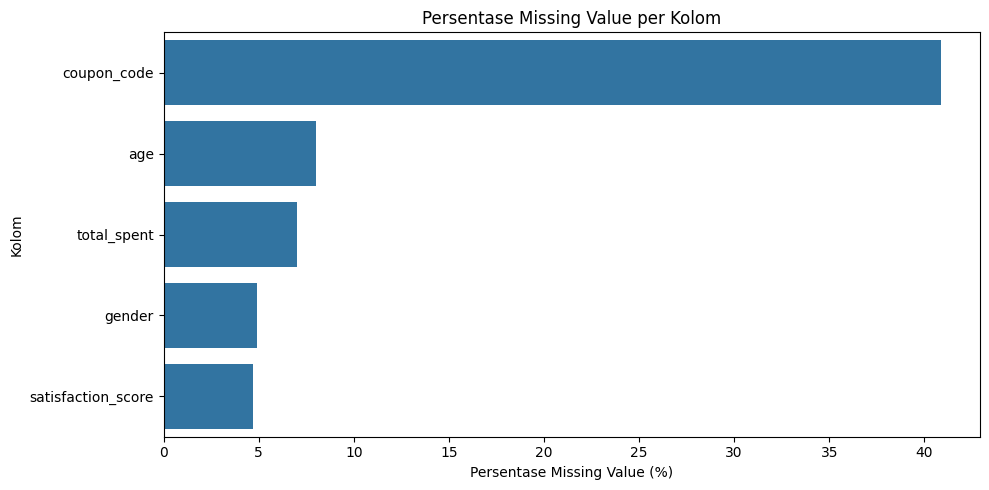

In [12]:
# Mengambil kolom yang memiliki missing value
missing_plot = missing_values[missing_values["missing_percentage"] > 0]

plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_plot.reset_index(),
    x="missing_percentage",
    y="index"
)

plt.title("Persentase Missing Value per Kolom")
plt.xlabel("Persentase Missing Value (%)")
plt.ylabel("Kolom")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribusi Target Churn

Distribusi target digunakan untuk melihat perbandingan jumlah pelanggan yang churn dan tidak churn. Bagian ini penting karena data churn sering memiliki distribusi kelas yang tidak seimbang.

In [13]:
# Menghitung distribusi target churn
churn_count = df["churn"].value_counts()
churn_percentage = df["churn"].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "count": churn_count,
    "percentage": churn_percentage
})

target_distribution

,count,percentage
churn,,
0,12702,84.68
1,2298,15.32


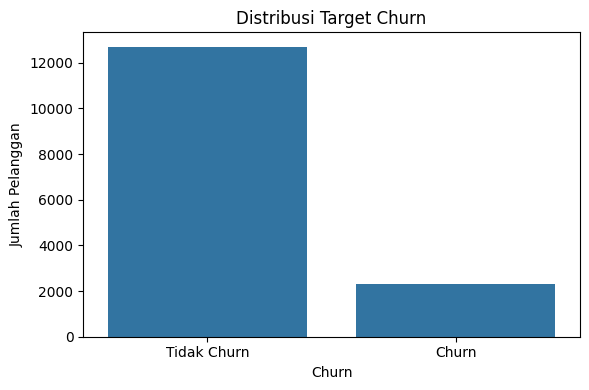

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn")

plt.title("Distribusi Target Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.xticks([0, 1], ["Tidak Churn", "Churn"])
plt.tight_layout()

plt.savefig(FIGURES_DIR / "churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Identifikasi Kolom Numerik dan Kategorikal

Kolom numerik dan kategorikal dipisahkan untuk memudahkan analisis. Kolom numerik digunakan pada analisis korelasi, sedangkan kolom kategorikal dapat dianalisis berdasarkan distribusi kategori.

In [15]:
# Memisahkan kolom numerik dan kategorikal
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Jumlah kolom numerik:", len(numeric_cols))
print(numeric_cols)

print("\nJumlah kolom kategorikal:", len(categorical_cols))
print(categorical_cols)

Jumlah kolom numerik: 20
['customer_id', 'age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']

Jumlah kolom kategorikal: 10
['gender', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']


## Korelasi Fitur Numerik

Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik. Korelasi juga dapat membantu melihat fitur mana yang memiliki hubungan cukup kuat dengan target `churn`.

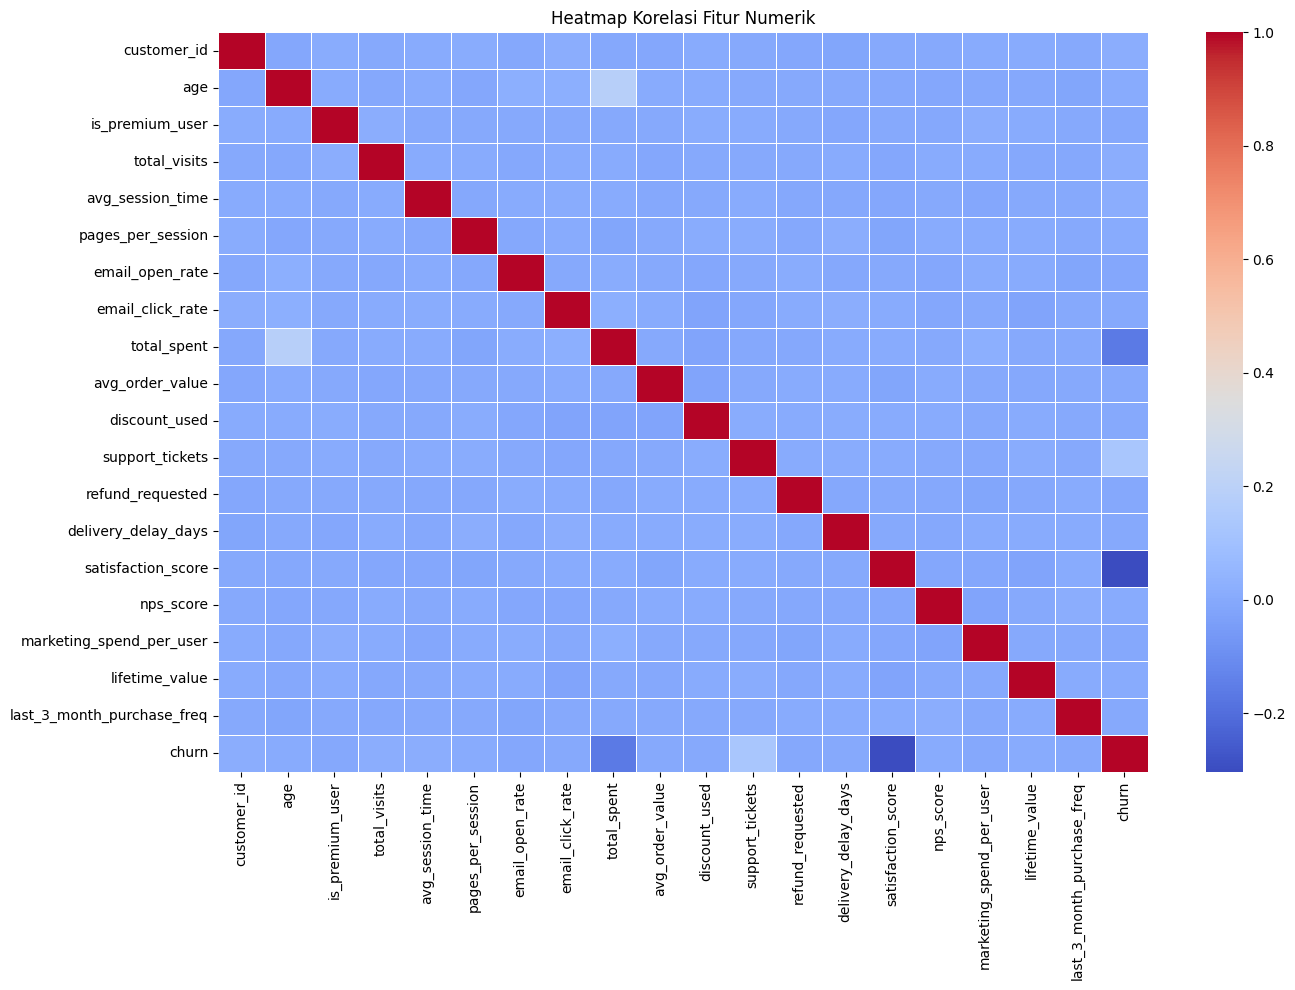

In [16]:
# Menghitung korelasi antar fitur numerik
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Korelasi Fitur Numerik terhadap Churn

Bagian ini menampilkan fitur numerik yang memiliki korelasi paling tinggi terhadap target `churn`.

In [17]:
# Melihat korelasi fitur numerik terhadap target churn
churn_correlation = corr_matrix["churn"].sort_values(ascending=False)

churn_correlation

churn                         1.000000
support_tickets               0.127910
total_visits                  0.013212
customer_id                   0.012208
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588
Name: churn, dtype: float64

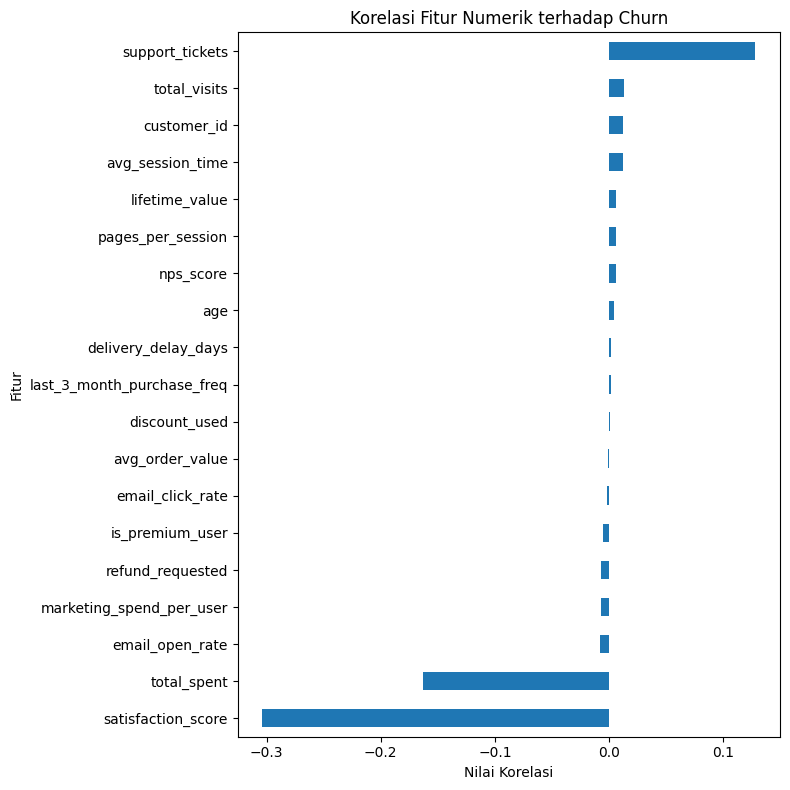

In [18]:
# Visualisasi korelasi fitur numerik terhadap churn
churn_corr_plot = churn_correlation.drop("churn").sort_values()

plt.figure(figsize=(8, 8))
churn_corr_plot.plot(kind="barh")

plt.title("Korelasi Fitur Numerik terhadap Churn")
plt.xlabel("Nilai Korelasi")
plt.ylabel("Fitur")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "churn_numeric_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Analisis Kanal Akuisisi Pelanggan

Kolom `acquisition_channel` digunakan untuk melihat sumber pelanggan. Analisis ini membantu memahami kanal pemasaran mana yang menghasilkan pelanggan dan bagaimana distribusi churn pada setiap kanal.

In [19]:
# Distribusi pelanggan berdasarkan acquisition channel
df["acquisition_channel"].value_counts()

acquisition_channel
Organic         3055
Google Ads      3047
Facebook Ads    3024
Referral        2941
Email           2933
Name: count, dtype: int64

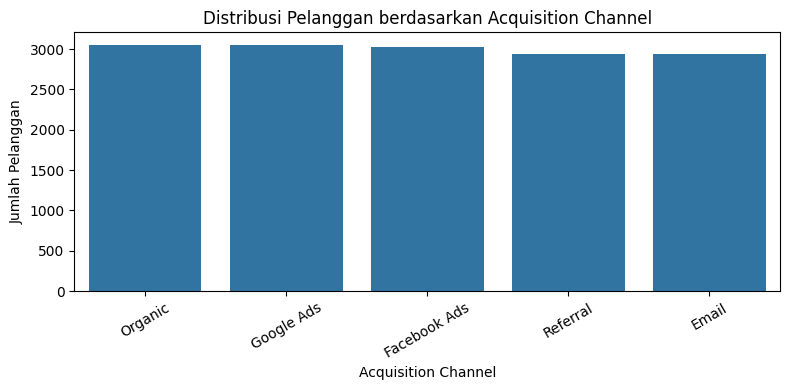

In [20]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="acquisition_channel", order=df["acquisition_channel"].value_counts().index)

plt.title("Distribusi Pelanggan berdasarkan Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Jumlah Pelanggan")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "acquisition_channel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Churn berdasarkan Acquisition Channel

Analisis ini digunakan untuk melihat perbandingan pelanggan churn dan tidak churn pada setiap kanal akuisisi.

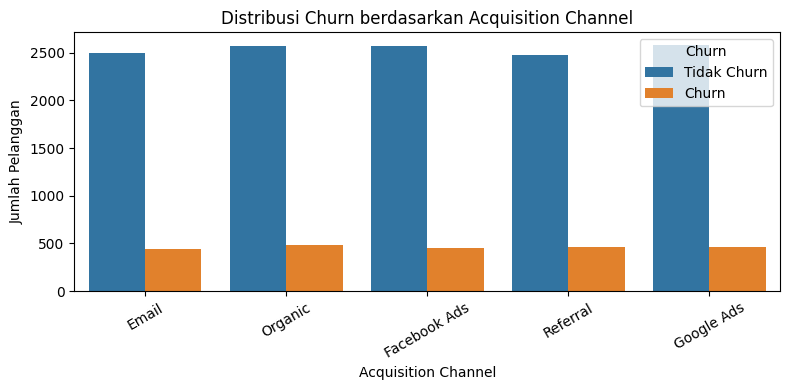

In [21]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="acquisition_channel", hue="churn")

plt.title("Distribusi Churn berdasarkan Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Jumlah Pelanggan")
plt.xticks(rotation=30)
plt.legend(title="Churn", labels=["Tidak Churn", "Churn"])
plt.tight_layout()

plt.savefig(FIGURES_DIR / "churn_by_acquisition_channel.png", dpi=150, bbox_inches="tight")
plt.show()

## Analisis Fitur Pemasaran dan Transaksi

Pada dataset ini, fitur pemasaran dan transaksi yang tersedia antara lain `marketing_spend_per_user`, `total_spent`, `avg_order_value`, `lifetime_value`, `email_open_rate`, dan `email_click_rate`.

Analisis ini dilakukan untuk melihat gambaran awal hubungan fitur tersebut dengan target churn.

In [22]:
marketing_features = [
    "marketing_spend_per_user",
    "total_spent",
    "avg_order_value",
    "lifetime_value",
    "email_open_rate",
    "email_click_rate",
    "churn"
]

df[marketing_features].describe()

,marketing_spend_per_user,total_spent,avg_order_value,lifetime_value,email_open_rate,email_click_rate,churn
count,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17.575238,524.357397,60.080882,1235.698200,0.496278,0.251231,0.153200
std,7.183437,467.050070,24.746203,657.521849,0.290108,0.144689,0.360192
min,5.000000,0.267291,0.071596,0.368886,0.000000,0.000000,0.000000
25%,11.380000,300.432074,43.032470,741.301251,0.240000,0.130000,0.000000
50%,17.630000,498.843859,60.108827,1216.210685,0.500000,0.250000,0.000000
75%,23.770000,702.396635,76.888445,1677.860399,0.750000,0.380000,0.000000
max,30.000000,15910.431879,154.554696,3767.490455,1.000000,0.500000,1.000000


In [23]:
# Rata-rata fitur pemasaran dan transaksi berdasarkan status churn
marketing_summary = df.groupby("churn")[marketing_features[:-1]].mean()

marketing_summary

,marketing_spend_per_user,total_spent,avg_order_value,lifetime_value,email_open_rate,email_click_rate
churn,,,,,,
0,17.597587,557.291795,60.096454,1233.950201,0.497319,0.251339
1,17.451706,347.791180,59.994808,1245.360118,0.490522,0.250635


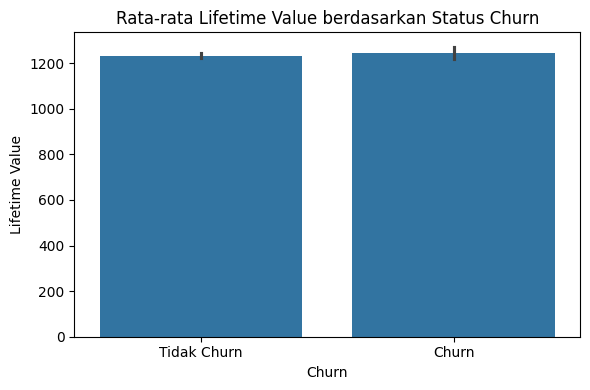

In [24]:
# Visualisasi rata-rata lifetime value berdasarkan status churn
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="churn", y="lifetime_value")

plt.title("Rata-rata Lifetime Value berdasarkan Status Churn")
plt.xlabel("Churn")
plt.ylabel("Lifetime Value")
plt.xticks([0, 1], ["Tidak Churn", "Churn"])
plt.tight_layout()

plt.savefig(FIGURES_DIR / "lifetime_value_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

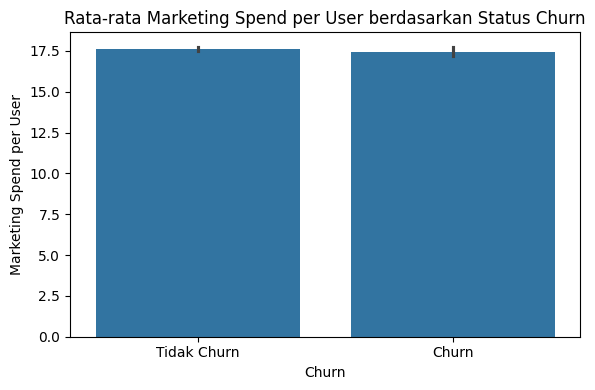

In [25]:
# Visualisasi rata-rata marketing spend berdasarkan status churn
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="churn", y="marketing_spend_per_user")

plt.title("Rata-rata Marketing Spend per User berdasarkan Status Churn")
plt.xlabel("Churn")
plt.ylabel("Marketing Spend per User")
plt.xticks([0, 1], ["Tidak Churn", "Churn"])
plt.tight_layout()

plt.savefig(FIGURES_DIR / "marketing_spend_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## Ringkasan Hasil EDA

Dari tahap EDA, beberapa hal utama yang diperoleh adalah:

- Dataset berhasil dimuat dan memiliki target prediksi `churn`.
- Terdapat beberapa kolom dengan missing value yang perlu ditangani pada tahap preprocessing.
- Distribusi target churn perlu diperhatikan karena dapat memengaruhi performa model klasifikasi.
- Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik.
- Beberapa fitur pemasaran dan transaksi dianalisis untuk melihat gambaran awal hubungannya dengan churn pelanggan.

Tahap EDA ini menjadi dasar untuk proses modeling pada tahap berikutnya.